# 2.EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# matplotlib のフォント設定を変更
plt.rcParams['font.family'] = 'sans-serif'

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.spatial.distance import cdist

In [2]:
# 入力：読み込みたい記述子のタイプを選択
descriptor_type = 'rdkit'  # 'rdkit' or 'mordred_2d' or 'mordred_3d'

# ベースのデータ
dataset = pd.read_csv("../data/dataset_train.csv", index_col=0)
# 目的変数（ターゲット）のみ抽出
target = dataset[["Stokes shift"]]

# 条件に応じて記述子ファイルを読み込む
if descriptor_type == "rdkit":
    des = pd.read_csv("outputs/descriptors/rdkit/X_train_rdkit_processed.csv", index_col=0)
    
elif descriptor_type == "mordred_2d":
    des = pd.read_csv("outputs/descriptors/mordred_2d/X_train_mordred_2d_processed.csv", index_col=0)

elif descriptor_type == "mordred_3d":
    des = pd.read_csv("outputs/descriptors/mordred_3d/X_train_mordred_3d_processed.csv",index_col=0)

elif descriptor_type == "fp":
    des = pd.read_csv("outputs/descriptors/fp/X_train_fp.csv", index_col=0)

else:
    raise ValueError(f"未知の descriptor_type: {descriptor_type}")

# 結合（目的変数 + 記述子）
dataset_train = target.join(des, how="inner")

# 確認
print(target.shape, des.shape, dataset_train.shape)

(15974, 1) (15974, 209) (15974, 210)


In [3]:
dataset_train.head()

,Stokes shift,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
Tag,,,,,,,,,,,,,,,,,,,,,
1,55.00,11.104717,11.104717,0.018850,-0.689259,0.631799,9.928571,187.154,182.114,187.026943,...,0,0,0,0,0,0,0,0,0,0
2,42.00,11.084309,11.084309,0.059121,-0.717037,0.568211,9.928571,186.146,182.114,186.019667,...,0,0,0,0,0,0,0,0,0,0
3,9.00,14.130123,14.130123,0.240638,-0.240770,0.013057,12.784810,1061.549,968.813,1060.705709,...,0,0,0,0,0,0,0,0,33,0
4,39.72,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,...,0,0,0,0,0,1,0,0,0,0
5,31.00,13.279579,13.279579,0.064638,0.064638,0.344339,12.000000,350.422,338.326,350.064509,...,0,0,0,0,0,1,0,0,0,0


## 可視化

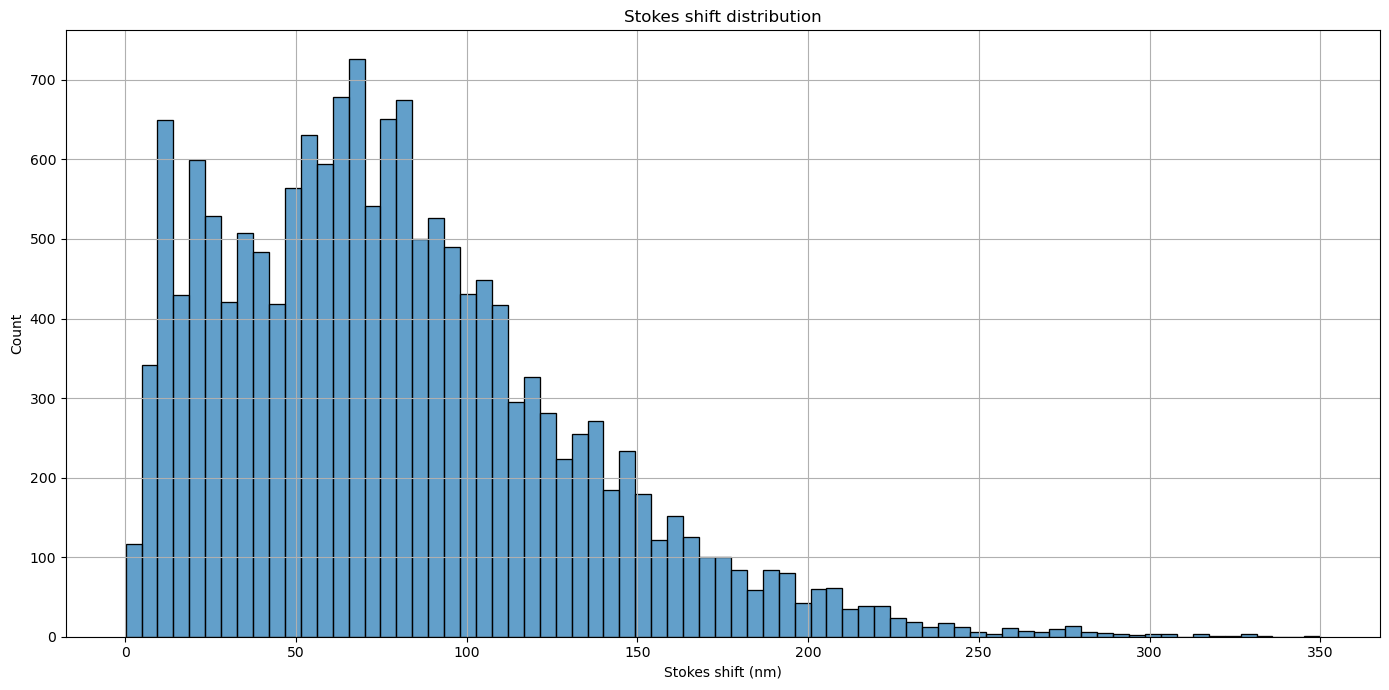

In [4]:
# Stokes shift のヒストグラム
plt.figure(figsize=(14, 7))
sns.histplot(
    data=dataset_train,
    x="Stokes shift",
    bins=75,
    alpha=0.7,
)

plt.xlabel("Stokes shift (nm)")
plt.ylabel("Count")
plt.title("Stokes shift distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

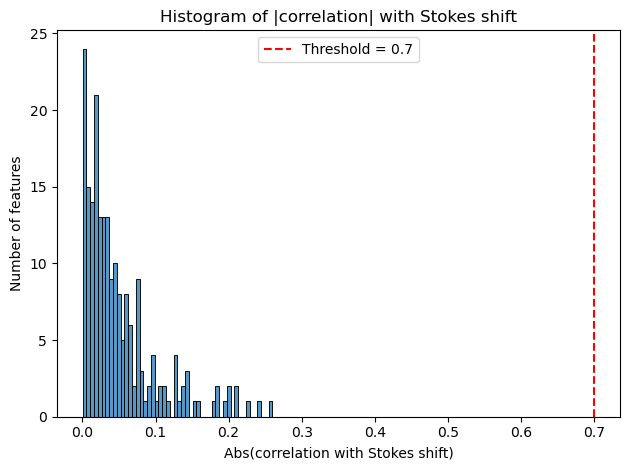

In [5]:
# 相関係数の計算（数値列のみ）
dataset_train_num = dataset_train.select_dtypes(include="number")
corr_coef = dataset_train_num.corr()

# 相関係数の絶対値（Stokes shift 自身との相関を除く）
target_col = "Stokes shift"
stokes_corr_abs = corr_coef[target_col].drop(target_col).abs()

# ヒストグラム描画
sns.histplot(stokes_corr_abs, bins=50)

plt.xlabel("Abs(correlation with Stokes shift)")
plt.ylabel("Number of features")
plt.title("Histogram of |correlation| with Stokes shift")
plt.axvline(x=0.7, color="red", linestyle="--", label="Threshold = 0.7")
plt.legend()
plt.tight_layout()
plt.show()

## PCA

In [6]:
# 目的変数
y = dataset_train['Stokes shift']
# 説明変数（標準偏差が０のものを除いたもの）
X = dataset_train.drop('Stokes shift', axis=1)

y.shape, X.shape

((15974,), (15974, 209))

In [7]:
# オートスケーリング
autoscaled_X = (X - X.mean()) / X.std()

In [8]:
# PCA
pca = PCA()
pca.fit(autoscaled_X)

# loading、各説明変数がその主成分に対してどれだけ寄与しているか
loading = pd.DataFrame(pca.components_.T, index=X.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# score、変換後の座標
score = pd.DataFrame(pca.transform(autoscaled_X), index=X.index, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

# 寄与率
cont_ratio = pd.DataFrame(pca.explained_variance_ratio_)
# 累積寄与率
cum_cont_ratio = cont_ratio.cumsum()
# 結合
cont_cumcont_ratio = pd.concat([cont_ratio, cum_cont_ratio], axis=1)
cont_cumcont_ratio.columns = ['contribution_ratio', 'cumulative_contribution_ratio']
cont_cumcont_ratio.index = [f'PC{i+1}' for i in cont_cumcont_ratio.index]

cont_cumcont_ratio.head(20)

,contribution_ratio,cumulative_contribution_ratio
PC1,0.191239,0.191239
PC2,0.084938,0.276178
PC3,0.044518,0.320695
PC4,0.034130,0.354826
PC5,0.031375,0.386200
PC6,0.025837,0.412037
PC7,0.024169,0.436206
PC8,0.021429,0.457635
PC9,0.019473,0.477109
PC10,0.018879,0.495988


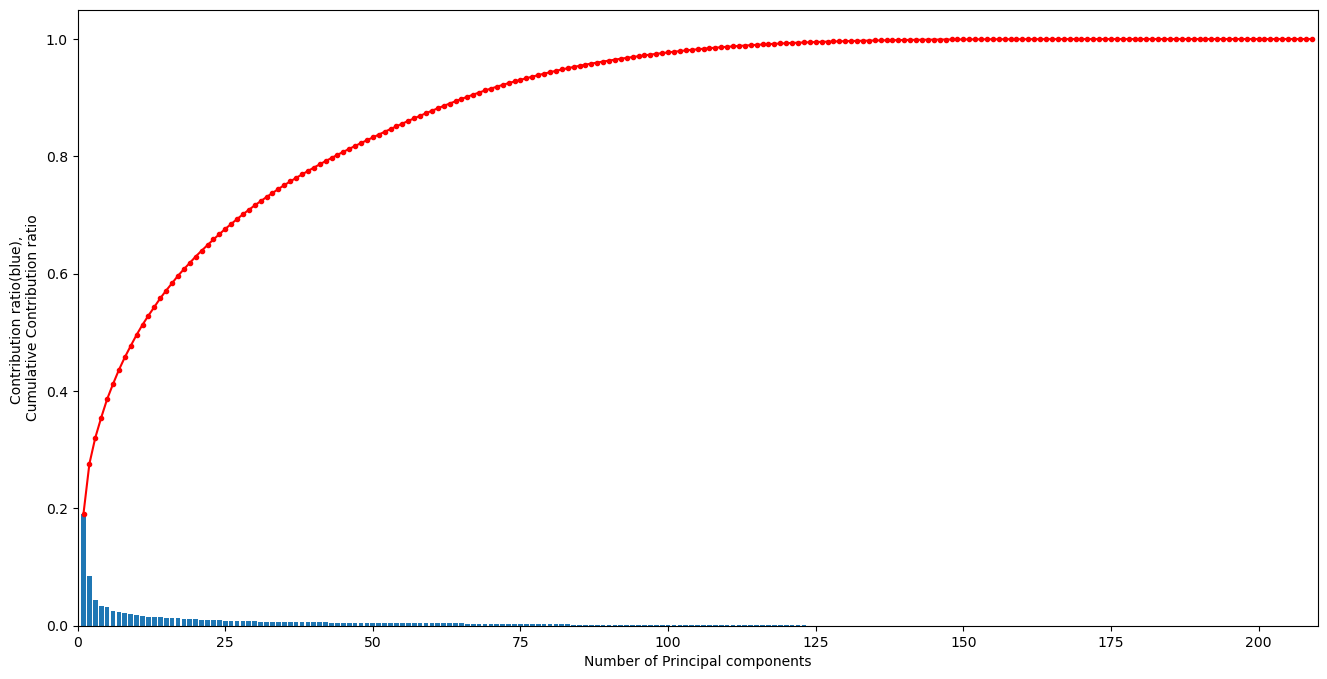

In [9]:
# 寄与率を折れ線で、累積寄与率を棒で可視化
x_axis = range(1, cont_cumcont_ratio.shape[0]+1)

# 図のサイズ
plt.figure(figsize=(16, 8))

# 棒グラフ
plt.bar(x_axis, cont_cumcont_ratio.iloc[:, 0], align='center')
# 折れ線
plt.plot(x_axis, cont_cumcont_ratio.iloc[:, 1], 'r.-')

plt.xlabel('Number of Principal components')
plt.ylabel('Contribution ratio(blue), \nCumulative Contribution ratio')
plt.xlim(0, cont_cumcont_ratio.shape[0]+1)

plt.show()

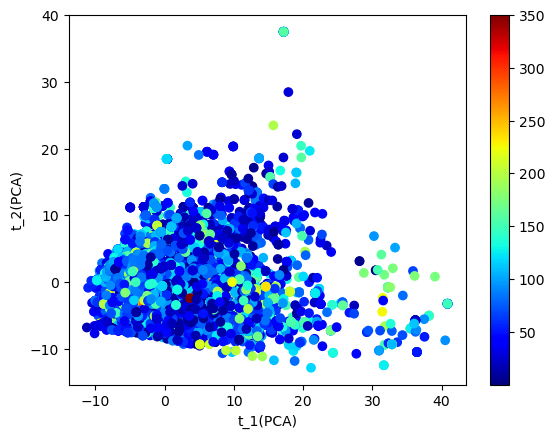

In [10]:
# 第一主成分と第二主成分の散布図
plt.scatter(score.iloc[:, 0], score.iloc[:, 1], c=y, cmap=plt.get_cmap('jet'))
plt.colorbar()

plt.xlabel('t_1(PCA)')
plt.ylabel('t_2(PCA)')

plt.show()

## t-SNE

In [ ]:
def k3n_error(x_1, x_2, k):
    """
    k-nearest neighbor normalized error (k3n-error)

    金子先生の手法、可視化する前のサンプル間のユークリッド距離と、可視化後のサンプル間のユークリッド距離に基づく方法

    サンプルの近接関係は多次元空間⇔2次元平面で保持されているか？ということで、細かく分けると、

    1. 多次元空間において近いサンプル同士は、2次元平面においても近いか？
    2. 2次元平面において近いサンプル同士は、多次元空間においても近いか？

    k3n_errorは1と2を同時に評価する、2つとも近ければよい。
    サンプル同士が近いほど、k3n_errorは小さくなる

    k3n-error = k3n-Z-error + k3n-X-error

    Parameters
    ----------
    x_1: numpy.array or pandas.DataFrame
    x_2: numpy.array or pandas.DataFrame
    k: int
        The numbers of neighbor

    Returns
    -------
    k3n_error : float
        k3n-Z-error or k3n-X-error
    """
    x_1 = np.array(x_1)
    x_2 = np.array(x_2)

    x_1_distance = cdist(x_1, x_1)
    x_1_sorted_indexes = np.argsort(x_1_distance, axis=1)
    x_2_distance = cdist(x_2, x_2)

    for i in range(x_2.shape[0]):
        _replace_zero_with_the_smallest_positive_values(x_2_distance[i, :])

    identity_matrix = np.eye(len(x_1_distance), dtype=bool)
    knn_distance_in_x_1 = np.sort(x_2_distance[:, x_1_sorted_indexes[:, 1:k + 1]][identity_matrix])
    knn_distance_in_x_2 = np.sort(x_2_distance)[:, 1:k + 1]

    sum_k3n_error = (
            (knn_distance_in_x_1 - knn_distance_in_x_2) / knn_distance_in_x_2
    ).sum()
    return sum_k3n_error / x_1.shape[0] / k

def _replace_zero_with_the_smallest_positive_values(arr):
    """
    Replace zeros in array with the smallest positive values.

    Parameters
    ----------
    arr: numpy.array
    """
    arr[arr == 0] = np.min(arr[arr != 0])

: 

In [ ]:
# k(近傍数)の数をサンプル数に応じて決定
n_samples = autoscaled_X.shape[0]
k_in_k3n_error = min(30, max(5, int(np.sqrt(n_samples))))  # 5〜30の範囲に制限

# perplexityの候補
candidates_of_perplexity = np.arange(5, 105, 5, dtype=int)

# k3n-errorを用いたperplexityの最適化
k3n_errors = []

for index, perplexity in enumerate(candidates_of_perplexity):
    # print(index + 1, '/', len(candidates_of_perplexity))

    # tsneの実行
    t = TSNE(perplexity=perplexity, n_components=2, init='pca', random_state=10).fit_transform(autoscaled_X)
    # tを標準化している
    scaled_t = (t-t.mean()) / t.std(axis=0, ddof=1)

    k3n_errors.append(k3n_error(autoscaled_X, scaled_t, k_in_k3n_error) + \
                      k3n_error(scaled_t, autoscaled_X, k_in_k3n_error))

# 最適な値を抽出
optimal_perplexity = candidates_of_perplexity[np.where(k3n_errors == np.min(k3n_errors))[0][0]]

print(f"使用するk（近傍数）: {k_in_k3n_error}")
print(f"最適なperplexity: {optimal_perplexity}")

In [ ]:
# 可視化
plt.scatter(candidates_of_perplexity, k3n_errors, c='blue')

# 右上に注釈を追加（位置は yのmax にちょっと足したくらい）
text_str = f'k = {k_in_k3n_error}\noptimal perplexity = {optimal_perplexity}'

plt.text(0.95, 0.95, text_str,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'))

plt.xlabel('perplexity')
plt.ylabel('k3n-errors')
plt.show()

In [ ]:
# 最適な値を抽出
optimal_perplexity = candidates_of_perplexity[np.where(k3n_errors == np.min(k3n_errors))[0][0]]
print('k3n-errorによるperplexityの最適解：', optimal_perplexity)

# t-SNE
t = TSNE(perplexity=optimal_perplexity, n_components=2,
         init='pca', random_state=10).fit_transform(autoscaled_X)

t = pd.DataFrame(t, index=X.index, columns=['t_1', 't_2'])

# t1とt2の散布図
plt.rcParams['font.size'] = 18
plt.scatter(t.iloc[:, 0], t.iloc[:, 1], c=y, cmap=plt.get_cmap('jet'))
plt.colorbar()

plt.xlabel('t_1(TSNE)')
plt.ylabel('t_2(TSNE)')
plt.show()